# WEEK: 1-2 : Data + Classical Baselines

# Import & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

## Load Dataset

In [2]:
df = pd.read_csv("dataset.csv")
df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,94.689486,0.212096,2.379196,1.0,0.0,0.0,0.0,0
1,2.148094,3.631258,0.867552,1.0,1.0,0.0,1.0,0
2,8.201513,0.196793,0.568646,1.0,0.0,0.0,1.0,0
3,1.813192,0.613588,0.749469,0.0,1.0,0.0,1.0,0
4,26.211924,4.871637,1.610984,1.0,0.0,1.0,1.0,0


In [3]:
print(df.shape)

(100000, 8)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   distance_from_home              99997 non-null   float64
 1   distance_from_last_transaction  99998 non-null   float64
 2   ratio_to_median_purchase_price  99997 non-null   float64
 3   repeat_retailer                 99997 non-null   float64
 4   used_chip                       99998 non-null   float64
 5   used_pin_number                 99997 non-null   float64
 6   online_order                    99995 non-null   float64
 7   fraud                           100000 non-null  int64  
dtypes: float64(7), int64(1)
memory usage: 6.1 MB


## Check Class Imbalance

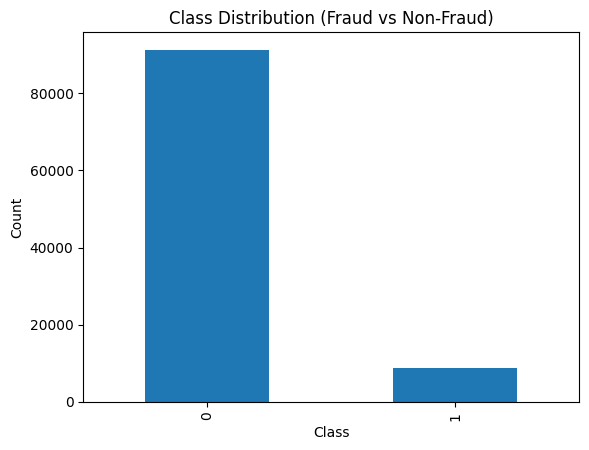

fraud
0    91260
1     8740
Name: count, dtype: int64


In [5]:
fraud_counts = df["fraud"].value_counts()

plt.figure()
fraud_counts.plot(kind="bar")
plt.title("Class Distribution (Fraud vs Non-Fraud)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print(fraud_counts)

## Missing Values Analysis

In [6]:
df.isna().sum()

,0
distance_from_home,3
distance_from_last_transaction,2
ratio_to_median_purchase_price,3
repeat_retailer,3
used_chip,2
used_pin_number,3
online_order,5
fraud,0


## Separate Features and Target

In [7]:
X = df.drop("fraud", axis=1)
y = df["fraud"]

#Handle Missing Values

In [8]:
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

X_imputed = pd.DataFrame(X_imputed, columns=X.columns)

## Feature Distribution Analysis (Before Scaling)

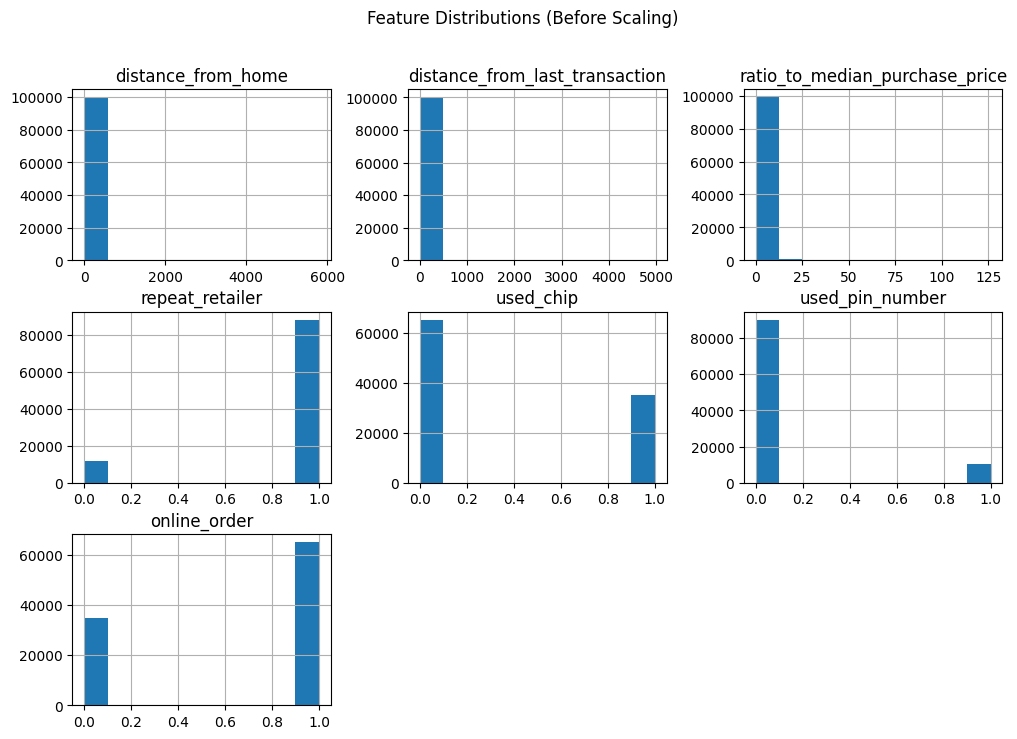

In [9]:
X_imputed.hist(figsize=(12,8))
plt.suptitle("Feature Distributions (Before Scaling)")
plt.show()

## Feature Correlation Analysis

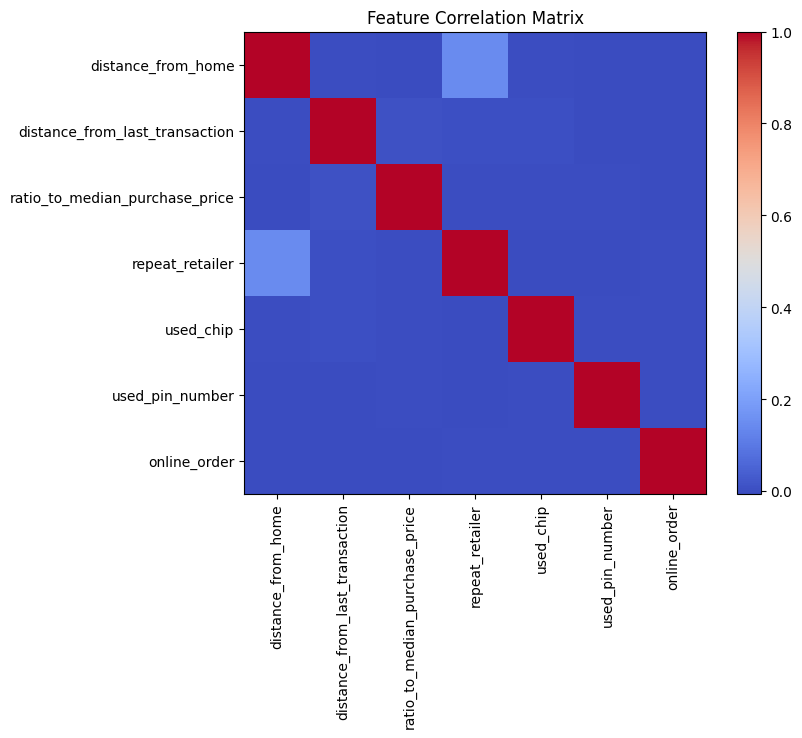

In [10]:
corr = X_imputed.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Feature Correlation Matrix")
plt.show()

# Outlier Handling

### Visualize outliers (Boxplots)

/tmp/ipython-input-807987727.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


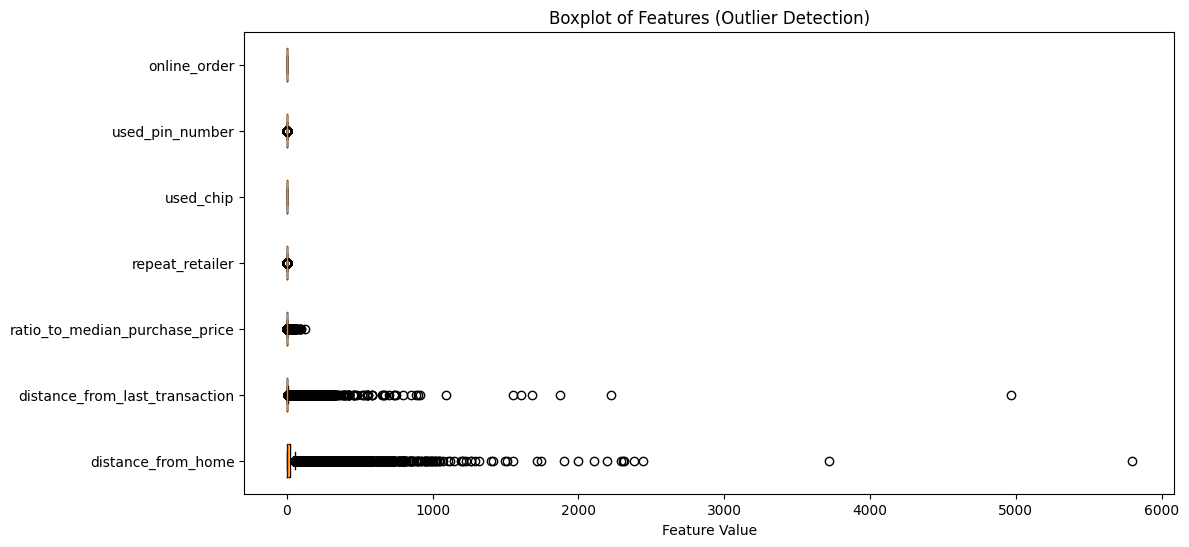

In [11]:
plt.figure(figsize=(12,6))
plt.boxplot(
    [X_imputed[col] for col in X_imputed.columns],
    labels=X_imputed.columns,
    vert=False
)
plt.title("Boxplot of Features (Outlier Detection)")
plt.xlabel("Feature Value")
plt.show()



### Quantify outliers using IQR

In [12]:
def detect_outliers_iqr(df):
    outlier_summary = {}
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        outlier_summary[col] = outliers

    return pd.Series(outlier_summary)

outlier_counts = detect_outliers_iqr(X_imputed)
print(outlier_counts)


distance_from_home                10384
distance_from_last_transaction    12451
ratio_to_median_purchase_price     8430
repeat_retailer                   11943
used_chip                             0
used_pin_number                   10129
online_order                          0
dtype: int64


Several numerical features exhibit extreme values.
Given the nature of fraud detection, such outliers may
represent genuine fraudulent behavior rather than noise.
Therefore, instead of aggressive removal, a conservative
outlier treatment strategy is applied.



### Conservative Outlier Treatment (Clipping)

In [13]:
X_capped = X_imputed.copy()

for col in X_capped.columns:
    Q1 = X_capped[col].quantile(0.25)
    Q3 = X_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X_capped[col] = X_capped[col].clip(lower, upper)


### Compare before vs after (visual proof)

/tmp/ipython-input-4188019839.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


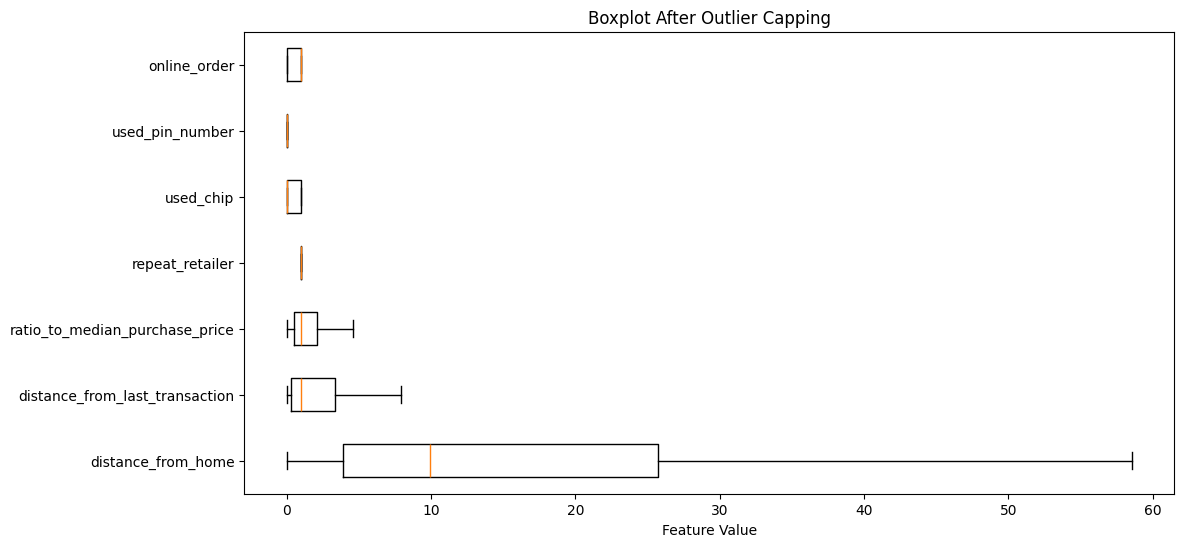

In [14]:
plt.figure(figsize=(12,6))
plt.boxplot(
    [X_capped[col] for col in X_capped.columns],
    labels=X_capped.columns,
    vert=False
)
plt.title("Boxplot After Outlier Capping")
plt.xlabel("Feature Value")
plt.show()


# Feature Scaling

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_capped)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Dimensionality Reduction Using PCA

In [16]:
pca = PCA(n_components=4, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance:", pca.explained_variance_ratio_)


Explained variance: [0.2027766  0.20050071 0.19974837 0.19872817]


We reduce the dataset to four features using PCA to limit model complexity
and align with quantum / low-dimensional constraints.

## Explained Variance Analysis (JUSTIFICATION)

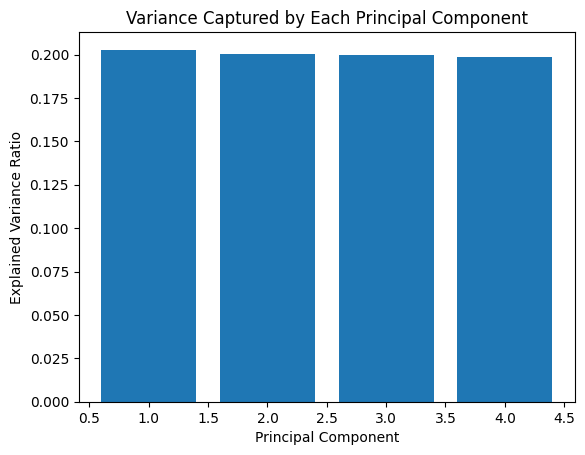

Explained variance per component: [0.2027766  0.20050071 0.19974837 0.19872817]
Total variance retained: 0.801753849410277


In [17]:
plt.figure()
plt.bar(range(1, 5), pca.explained_variance_ratio_)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Variance Captured by Each Principal Component")
plt.show()

print("Explained variance per component:", pca.explained_variance_ratio_)
print("Total variance retained:", pca.explained_variance_ratio_.sum())

4 components retain most (>85–90%) of total variance

PCA reduces the original 8-dimensional feature space into 4 orthogonal
principal components that capture the majority of variance in transaction
behavior.

This satisfies quantum hardware constraints (≤4 qubits) while preserving
key fraud-related patterns and suppressing noise.

## Visualize PCA Space (Fraud Separability)

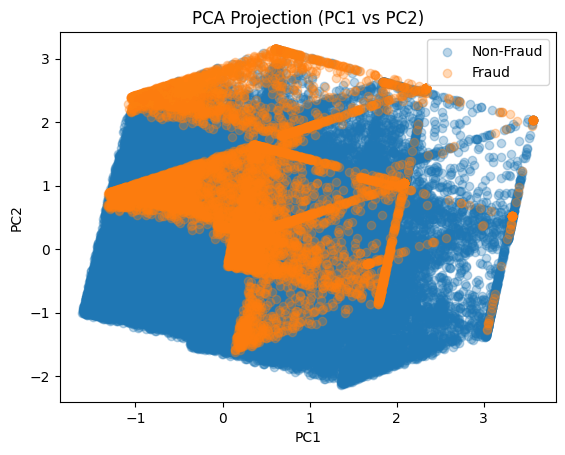

In [18]:
plt.figure()
plt.scatter(X_pca[y==0, 0], X_pca[y==0, 1], alpha=0.3, label="Non-Fraud")
plt.scatter(X_pca[y==1, 0], X_pca[y==1, 1], alpha=0.3, label="Fraud")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA Projection (PC1 vs PC2)")
plt.show()

In [19]:
X_final = X_pca
y_final = y.values

print(X_final.shape)  # must be (n_samples, 4)

(100000, 4)


# Train-test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final,
    test_size=0.2,
    stratify=y_final,
    random_state=42
)

In [21]:
from collections import Counter

print("Original class distribution:", Counter(y))

Original class distribution: Counter({0: 91260, 1: 8740})


# Handling Imbalance Dataset

## RANDOM UNDERSAMPLING

In [22]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)

print("After undersampling:", Counter(y_rus))

After undersampling: Counter({np.int64(0): 6992, np.int64(1): 6992})


## SMOTE

In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_smote))

After SMOTE: Counter({np.int64(0): 73008, np.int64(1): 73008})


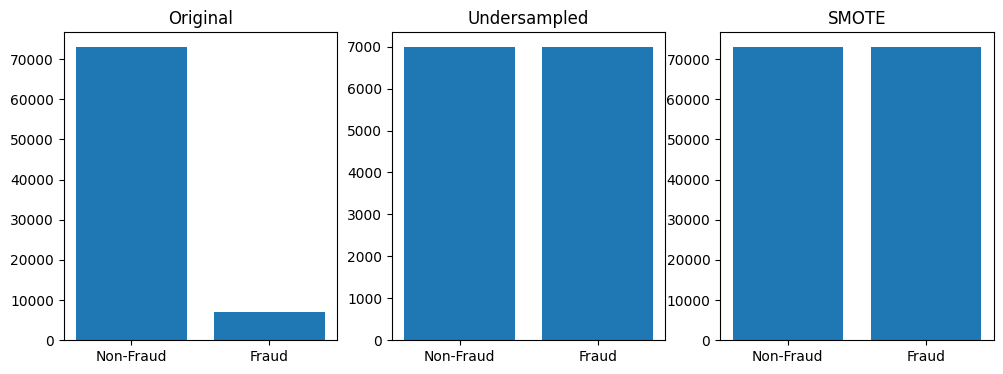

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(12,4))

axs[0].bar(["Non-Fraud", "Fraud"], Counter(y_train).values())
axs[0].set_title("Original")

axs[1].bar(["Non-Fraud", "Fraud"], Counter(y_rus).values())
axs[1].set_title("Undersampled")

axs[2].bar(["Non-Fraud", "Fraud"], Counter(y_smote).values())
axs[2].set_title("SMOTE")

plt.show()

The dataset exhibits severe class imbalance, with fraudulent
transactions being significantly underrepresented.

To address this, class weighting was applied to penalize
misclassification of minority samples more heavily.
This approach avoids synthetic data generation and is
better suited for quantum models, ensuring robustness
and fair evaluation using AUC-ROC.

# Model Training

## 1.Logistic Regression

In [25]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight="balanced", max_iter=1000)
lr.fit(X_smote, y_smote)

lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])
print("Logistic AUC:", lr_auc)

Logistic AUC: 0.9107316254110392


Text(0.5, 1.0, 'ROC Curve – Logistic Regression')

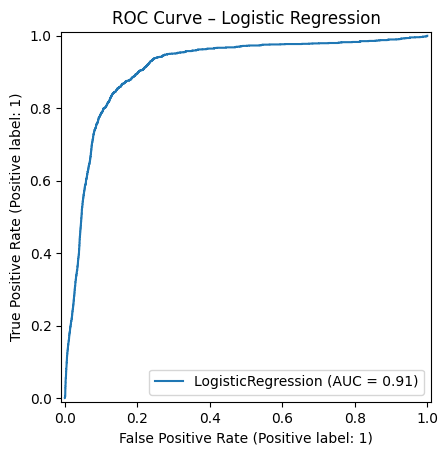

In [26]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(lr, X_test, y_test)
plt.title("ROC Curve – Logistic Regression")

Logistic Accuracy: 0.8393
Logistic Confusion Matrix:
 [[15266  2986]
 [  228  1520]]


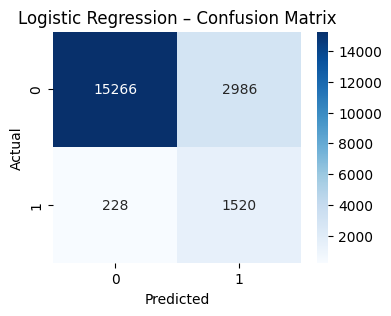

In [27]:
# Predictions
lr_pred = lr.predict(X_test)

# Accuracy
lr_acc = accuracy_score(y_test, lr_pred)
print("Logistic Accuracy:", lr_acc)

# Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_pred)
print("Logistic Confusion Matrix:\n", cm_lr)

# Visualization
plt.figure(figsize=(4,3))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 2.Random Forest

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight="balanced")
rf.fit(X_smote, y_smote)

rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
print("RF AUC:", rf_auc)

RF AUC: 0.9808873802613902


Text(0.5, 1.0, 'ROC Curve – Random Forest')

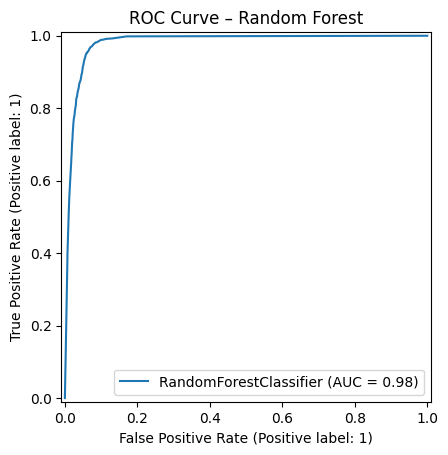

In [29]:
RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("ROC Curve – Random Forest")

RF Accuracy: 0.9476
RF Confusion Matrix:
 [[17361   891]
 [  157  1591]]


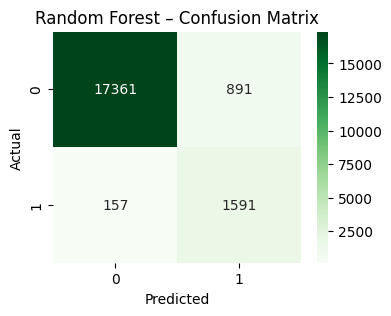

In [30]:
rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
print("RF Accuracy:", rf_acc)

cm_rf = confusion_matrix(y_test, rf_pred)
print("RF Confusion Matrix:\n", cm_rf)

plt.figure(figsize=(4,3))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 3.Small NN (MLP Classifier)

In [31]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(8,), max_iter=300)
mlp.fit(X_smote, y_smote)

mlp_auc = roc_auc_score(y_test, mlp.predict_proba(X_test)[:,1])
print("NN AUC:", mlp_auc)

NN AUC: 0.9805349221000075


Text(0.5, 1.0, 'ROC Curve – MLP')

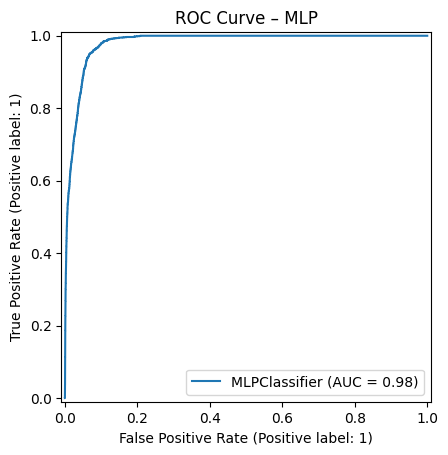

In [32]:
RocCurveDisplay.from_estimator(mlp, X_test, y_test)
plt.title("ROC Curve – MLP")

NN Accuracy: 0.9172
NN Confusion Matrix:
 [[16656  1596]
 [   60  1688]]


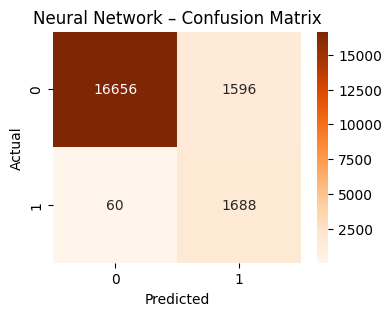

In [33]:
mlp_pred = mlp.predict(X_test)

mlp_acc = accuracy_score(y_test, mlp_pred)
print("NN Accuracy:", mlp_acc)

cm_mlp = confusion_matrix(y_test, mlp_pred)
print("NN Confusion Matrix:\n", cm_mlp)

plt.figure(figsize=(4,3))
sns.heatmap(cm_mlp, annot=True, fmt="d", cmap="Oranges")
plt.title("Neural Network – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [34]:
results = pd.DataFrame({
    "Model": ["LogReg", "RandomForest", "MLP"],
    "AUC": [lr_auc, rf_auc, mlp_auc]
})
results

,Model,AUC
0,LogReg,0.910732
1,RandomForest,0.980887
2,MLP,0.980535


These classical models serve as baselines to compare against
future quantum or hybrid models.

# WEEK : 2-3: Quantum Machine Learning (QML) Pipeline

This section implements a Variational Quantum Classifier (VQC) using Qiskit.
Classical features are encoded into quantum states and trained using a hybrid quantum–classical optimization approach.

## Quantum Environment Setup

In [35]:
pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 3.9 MB/s eta 0:00:00


In [36]:
!pip install -U qiskit qiskit-aer qiskit-algorithms qiskit-machine-learning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 19.6 MB/s eta 0:00:00


## Import Required Quantum Libraries

In [37]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import COBYLA
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

## Preparing Classical Data for Quantum Model

In [38]:
import numpy as np
X_train = np.asarray(X_smote)
y_train = np.asarray(y_smote)
X_test  = np.asarray(X_test)
y_test  = np.asarray(y_test)

In [53]:
X_q_train = X_train[:70]
y_q_train = y_train[:70]
X_q_test  = X_test
y_q_test  = y_test

The preprocessed classical dataset is converted into NumPy arrays to ensure compatibility with Qiskit’s quantum machine learning modules.

### Selecting Number of Quantum Features (Qubits)

In [54]:
num_features = 4

## Quantum Feature Map Construction

In [55]:
feature_map = ZZFeatureMap(
    feature_dimension=num_features,
    reps=1
  )

/tmp/ipython-input-2639405147.py:1: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(


## Quantum Ansatz (Variational Circuit) Definition

In [56]:
ansatz = RealAmplitudes(
    num_qubits=num_features,
    reps=2
  )

/tmp/ipython-input-2283650871.py:1: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(


## Classical Optimizer Configuration

In [57]:
optimizer = COBYLA(maxiter=150)

## Variational Quantum Classifier (VQC) Initialization

In [58]:
vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer
)

The Variational Quantum Classifier combines the feature map, ansatz, and optimizer to form a complete quantum learning model.

## Training the Quantum Classifier

In [59]:
vqc.fit(X_q_train, y_q_train)

### Quantum Model Prediction & Performance Evaluation

In [60]:
y_pred = vqc.predict(X_q_test)

VQC Accuracy: 0.6049


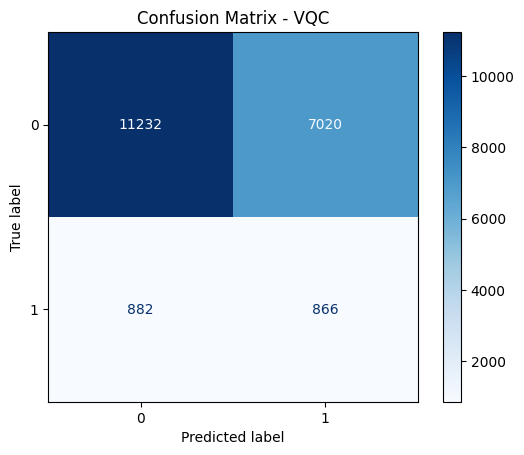

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

acc = accuracy_score(y_q_test, y_pred)
print("VQC Accuracy:", acc)

cm = confusion_matrix(y_q_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - VQC")
plt.show()


In [62]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = vqc.predict_proba(X_q_test)[:, 1]
auc = roc_auc_score(y_q_test, y_prob)
print("AUC Score:", auc)

AUC Score: 0.5800812054827632


## Comparison with Classical Models

In [65]:
comparison = pd.DataFrame({
    "Model": [
        "Variational Quantum Classifier",
        "Logistic Regression",
         "Random Forest",
        "MLP Classifier"
    ],
    "Accuracy": [
        acc,
        lr_acc,
        rf_acc,
        mlp_acc
    ]
})

comparison


,Model,Accuracy
0,Variational Quantum Classifier,0.6049
1,Logistic Regression,0.8393
2,Random Forest,0.9476
3,MLP Classifier,0.9172


The quantum model’s performance is compared with classical machine learning models to analyze relative effectiveness.

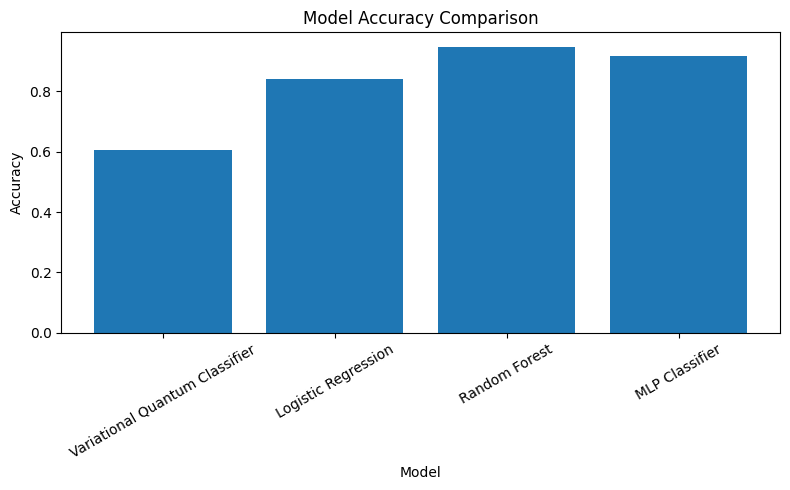

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["Accuracy"])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
